In [6]:
from abc import ABC, abstractmethod
from typing import Optional
import math

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - drift_coefficient: shape (batch_size, dim)
        """
        pass

class SDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the SDE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - drift_coefficient: shape (batch_size, dim)
        """
        pass

    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the SDE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - diffusion_coefficient: shape (batch_size, dim)
        """
        pass

class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        """
        Takes one simulation step
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
            - dt: time, shape ()
        Returns:
            - nxt: state at time t + dt
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state at time ts[0], shape (batch_size, dim)
            - ts: timesteps, shape (nts,)
        Returns:
            - x_fina: final state at time ts[-1], shape (batch_size, dim)
        """
        for t_idx in range(len(ts) - 1):
            t = ts[t_idx]
            h = ts[t_idx + 1] - ts[t_idx]
            x = self.step(x, t, h)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state at time ts[0], shape (bs, dim)
            - ts: timesteps, shape (num_timesteps,)
        Returns:
            - xs: trajectory of xts over ts, shape (batch_size, num_timesteps, dim)
        """
        xs = [x.clone()]
        for t_idx in tqdm(range(len(ts) - 1)):
            t = ts[t_idx]
            h = ts[t_idx + 1] - ts[t_idx]
            x = self.step(x, t, h)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)


# Simulations
## Euler ODE Simulator

In [9]:
class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        xt_h = xt + h * self.ode.drift_coefficient(xt, t)
        return xt_h

## Euler Maruyama Simulator

In [11]:
class EulerMaruyamaSimulator(Simulator):
    def __init__(self, sde: SDE):
        self.sde = sde
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        xt_h = xt + h * self.sde.drift_coefficient(xt, t) + math.sqrt(h) * self.sde.diffusion_coefficient(xt, t)
        return xt_h

# Visualization to SDEs
## Brownian Motion

In [23]:
class BrownianMotion(SDE):
    def __init__(self, sigma: float):
        self.sigma = sigma
        
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - drift: shape (bs, dim)
        """
        return torch.zeros_like(xt)

    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """`
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - diffusion: shape (bs, dim)
        """
        e = torch.randn_like(xt)
        return self.sigma * torch.ones_like(xt) * e
        


In [17]:
def plot_trajectories_1d(x0: torch.Tensor, simulator: Simulator, timesteps: torch.Tensor, ax: Optional[Axes] = None, show_hist: bool = False, decouple_hist_axis: bool = False):
        """
        Graphs the trajectories of a one-dimensional SDE with given initial values (x0) and simulation timesteps (timesteps).
        Args:
            - x0: state at time t, shape (num_trajectories, 1)
            - simulator: Simulator object used to simulate
            - t: timesteps to simulate along, shape (num_timesteps,)
            - ax: pyplot Axes object to plot on
            - decouple_hist_axis: if True, do not share y-axis between trajectories and histogram
        """
        if ax is None:
            ax = plt.gca()
        trajectories = simulator.simulate_with_trajectory(x0, timesteps) # (num_trajectories, num_timesteps, ...)

        line_color = sns.color_palette("crest", 1)[0]
        hist_color = sns.color_palette("flare", 1)[0]
        label_size = 12
        tick_size = 10

        timesteps_cpu = timesteps.detach().cpu().numpy()
        for trajectory_idx in range(trajectories.shape[0]):
            trajectory = trajectories[trajectory_idx, :, 0].detach().cpu().numpy() # (num_timesteps,)
            sns.lineplot(
                x=timesteps_cpu,
                y=trajectory,
                ax=ax,
                color=line_color,
                alpha=0.45,
                linewidth=1.1,
                legend=False,
            )

        ax.set_xlabel(r"time ($t$)", fontsize=label_size)
        ax.set_ylabel(r"$X_t$", fontsize=label_size)
        ax.tick_params(axis='both', labelsize=tick_size)
        ax.grid(alpha=0.2, linewidth=0.6)

        if show_hist:
            terminal_points = trajectories[:, -1, 0].detach().cpu().numpy()
            data_range = float(terminal_points.max() - terminal_points.min()) if terminal_points.size else 1.0
            binwidth = max(data_range / 25.0, 0.05)

            from mpl_toolkits.axes_grid1 import make_axes_locatable
            divider = make_axes_locatable(ax)
            sharey = None if decouple_hist_axis else ax
            hist_ax = divider.append_axes("right", size="22%", pad=0.45, sharey=sharey)
            sns.histplot(
                y=terminal_points,
                ax=hist_ax,
                binwidth=binwidth,
                color=hist_color,
                alpha=0.7,
                edgecolor="white",
                linewidth=0.5,
            )
            hist_ax.set_xlabel("count", fontsize=label_size)
            hist_ax.set_ylabel("")
            hist_ax.tick_params(axis='both', labelsize=tick_size)
            if decouple_hist_axis:
                hist_ax.tick_params(axis='y', left=True, labelleft=True)
            else:
                hist_ax.tick_params(axis='y', left=False, labelleft=False)
            hist_ax.grid(axis='x', alpha=0.2, linewidth=0.6)

        fig = ax.figure
        if fig is not None:
            title = ax.get_title()
            if title:
                title_size = ax.title.get_fontsize()
                ax.set_title("")

                axes = [ax]
                if show_hist:
                    axes.append(hist_ax)

                fig.canvas.draw()
                bboxes = [a.get_position() for a in axes]

                left = min(b.x0 for b in bboxes)
                right = max(b.x1 for b in bboxes)
                top = max(b.y1 for b in bboxes)

                x_center = 0.5 * (left + right)
                y = top + 0.005

                fig.text(
                    x_center,
                    y,
                    title,
                    ha="center",
                    va="bottom",
                    fontsize=title_size,
                )



100%|████████████████████████████████████████████████████| 499/499 [00:00<00:00, 23649.24it/s]


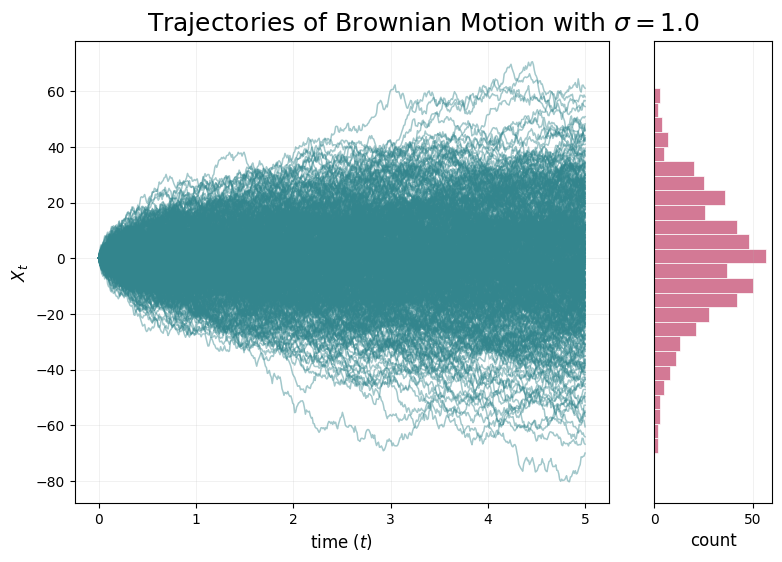

In [24]:
sigma = 1.0
n_traj = 500
brownian_motion = BrownianMotion(sigma)
simulator = EulerMaruyamaSimulator(sde=brownian_motion)
x0 = torch.zeros(n_traj,1).to(device) # Initial values - let's start at zero
ts = torch.linspace(0.0,5.0,500).to(device) # simulation timesteps

plt.figure(figsize=(9, 6))
ax = plt.gca()
ax.set_title(r'Trajectories of Brownian Motion with $\sigma=$' + str(sigma), fontsize=18)
ax.set_xlabel(r'time ($t$)', fontsize=18)
ax.set_ylabel(r'$x_t$', fontsize=18)
plot_trajectories_1d(x0, simulator, ts, ax, show_hist=True)
plt.show()